In [1]:
%matplotlib inline
from matplotlib_venn import venn2, venn2_circles
from matplotlib_venn import venn3, venn3_circles
from matplotlib import pyplot as plt
from venn import pseudovenn,venn6
import pandas as pd
import venn

In [2]:
from google.cloud import bigquery
from google.oauth2 import service_account
credentials = service_account.Credentials.from_service_account_file('/Users/shubham/Desktop/Visualization/SWOO-Analytics-BQ-7ef282b1d58b.json')
project_id = 'swoo-analytics-bq'
client = bigquery.Client(credentials= credentials,project=project_id)

In [5]:
query_job = client.query("""
SELECT a.device_channel , b.body_name
FROM (
SELECT distinct device_channel
from `swoo_plus_db.ua_pro_game_derived_data_v1` 
WHERE body_name IN ("allconteststab_open") ) a
LEFT JOIN (
SELECT device_channel, body_name
FROM `swoo_plus_db.ua_pro_game_derived_data_v1` 
WHERE date = "2019-06-20"
AND body_name IN ("pay2playgamepage_startedplaying","videoplayer_open","livegamestab_open")
GROUP BY 1,2 ) b
ON a.device_channel = b.device_channel
WHERE body_name is not null
""")
data = query_job.to_dataframe()

In [6]:
data.head(10)

,device_channel,body_name
0,8a645cfa-d40e-491a-ab67-6ad372dcdaa7,pay2playgamepage_startedplaying
1,8a645cfa-d40e-491a-ab67-6ad372dcdaa7,videoplayer_open
2,0c8bd620-fb8e-4f0c-961c-9f9c771bf2a5,pay2playgamepage_startedplaying
3,0c8bd620-fb8e-4f0c-961c-9f9c771bf2a5,livegamestab_open
4,daa7dbd7-9f8a-4328-b667-3830498402e8,pay2playgamepage_startedplaying
5,191479b4-c539-4172-94b9-35e23c4271e7,pay2playgamepage_startedplaying
6,8aceda3f-879c-4971-ac32-dab01aca5d4f,pay2playgamepage_startedplaying
7,8aceda3f-879c-4971-ac32-dab01aca5d4f,livegamestab_open
8,43f92f9e-da32-4e1b-a388-3c5956f0caea,livegamestab_open
9,1aaad231-a8a7-43ee-b22c-2406b0561b6a,livegamestab_open


In [7]:
data[data.body_name == 'pay2playgamepage_startedplaying'].device_channel.nunique()

1309

In [8]:
data[data.body_name == 'videoplayer_open'].device_channel.nunique()

1547

In [9]:
data[data.body_name == 'livegamestab_open'].device_channel.nunique()

2812

In [10]:
live_games = pd.DataFrame()
live_games['device_channel'] = data[data['body_name'] != 'pay2playgamepage_startedplaying']['device_channel']
p2p_games = pd.DataFrame()
p2p_games['device_channel'] = data[data['body_name'] == "pay2playgamepage_startedplaying"]['device_channel']


In [11]:
live_games1 = []
p2p_games1 = []
live_games1 = set(live_games['device_channel'])
p2p_games1 = set(p2p_games['device_channel'])

/anaconda3/lib/python3.7/site-packages/venn/_backwards_compatibility.py:16: UserWarning: `get_labels()` is retained for backwards compatibility; use `generate_petal_labels()` or the higher level `venn()` instead
  "`get_labels()` is retained for backwards compatibility; " +
/anaconda3/lib/python3.7/site-packages/venn/_backwards_compatibility.py:32: UserWarning: `venn2()` is retained for backwards compatibility; use `venn()` instead
  "use `venn()` instead"
/anaconda3/lib/python3.7/site-packages/matplotlib/figure.py:445: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  % get_backend())


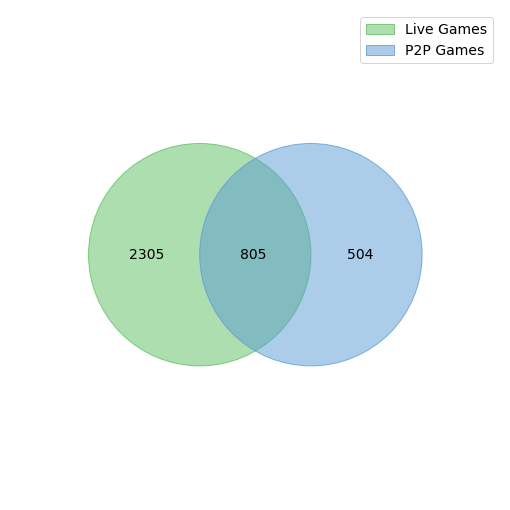

In [12]:
import matplotlib.pyplot as plt
import venn
labels = venn.get_labels([live_games1,p2p_games1])
fig, ax = venn.venn3(labels, names=['Live Games', 'P2P Games']) #,figsize=(21, 14)
#plt.savefig('venn_p2p_0804_1404')
plt.savefig('venn_1504_2104')
fig.show()

In [13]:
p2p_play = pd.DataFrame()
p2p_play['device_channel'] = data['device_channel'][data['body_name'] == "pay2playgamepage_startedplaying"]
video_player = pd.DataFrame()
video_player['device_channel'] = data['device_channel'][data['body_name'] == "videoplayer_open"]
live_games = pd.DataFrame()
live_games['device_channel'] = data['device_channel'][data['body_name'] == "livegamestab_open"]

In [14]:
p2p_play = set(p2p_play['device_channel'])
video_player = set(video_player['device_channel'])
live_games = set(live_games['device_channel'])


/anaconda3/lib/python3.7/site-packages/venn/_backwards_compatibility.py:32: UserWarning: `venn3()` is retained for backwards compatibility; use `venn()` instead
  "use `venn()` instead"


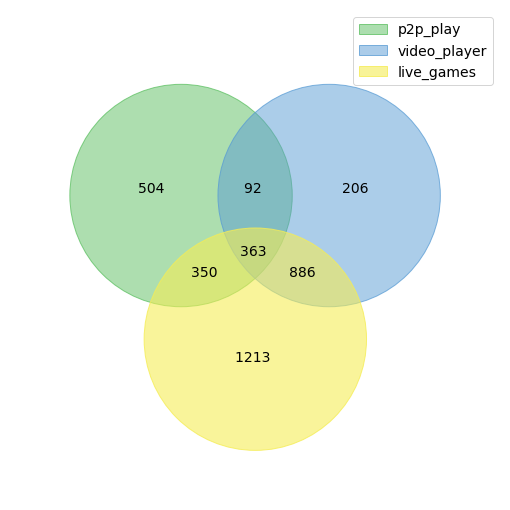

In [15]:
import matplotlib.pyplot as plt
import venn
labels = venn.get_labels([p2p_play,video_player,live_games])
fig, ax = venn.venn3(labels, names=['p2p_play', 'video_player', 'live_games']) #,figsize=(21, 14)
#plt.savefig('venn_0804_1404')
plt.savefig('venn_funnel')
fig.show()